# Black–Scholes Greeks

This notebook calculates and visualises the sensitivities of a European
call option under the Black–Scholes model.

If the call price is written as

$$
C=C(S,K,r,\sigma,\tau),
$$

then the main Greeks are:

- Delta: sensitivity to the underlying price $S$;
- Gamma: sensitivity of Delta to $S$;
- Vega: sensitivity to volatility $\sigma$;
- Theta: sensitivity to the passage of time.

Here, $\tau$ denotes the time remaining until maturity.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

## Delta

Delta measures the sensitivity of the option price to a small change in
the underlying asset price:

$$
\Delta=\frac{\partial C}{\partial S}.
$$

For a European call option,

$$
\Delta_{\text{call}}=N(d_1).
$$

For a small change $\Delta S$,

$$
\Delta C\approx \Delta_{\text{call}}\Delta S.
$$

This is a local linear approximation, so it becomes less accurate for
large changes in the underlying price.

In [2]:
def calculate_d1(S, K, r, sigma, tau):
    """Calculate d1 in the Black-Scholes model."""

    return (
        np.log(S / K)
        + (r + 0.5 * sigma**2) * tau
    ) / (sigma * np.sqrt(tau))


def call_delta(S, K, r, sigma, tau):
    """ Calculate the Delta of a European call option."""

    d1 = calculate_d1(S, K, r, sigma, tau)
    return norm.cdf(d1)

In [3]:
S = 100
K = 100
r = 0.05
sigma = 0.20
tau = 1

delta = call_delta(S, K, r, sigma, tau)

print(f"Call Delta: {delta:.4f}")

Call Delta: 0.6368


### Delta Across Underlying Prices

A call option that is far out of the money has Delta close to zero,
because a small change in the underlying price has little effect on its
value.

A call option that is deep in the money has Delta close to one, because
its price moves approximately one-for-one with the underlying asset.

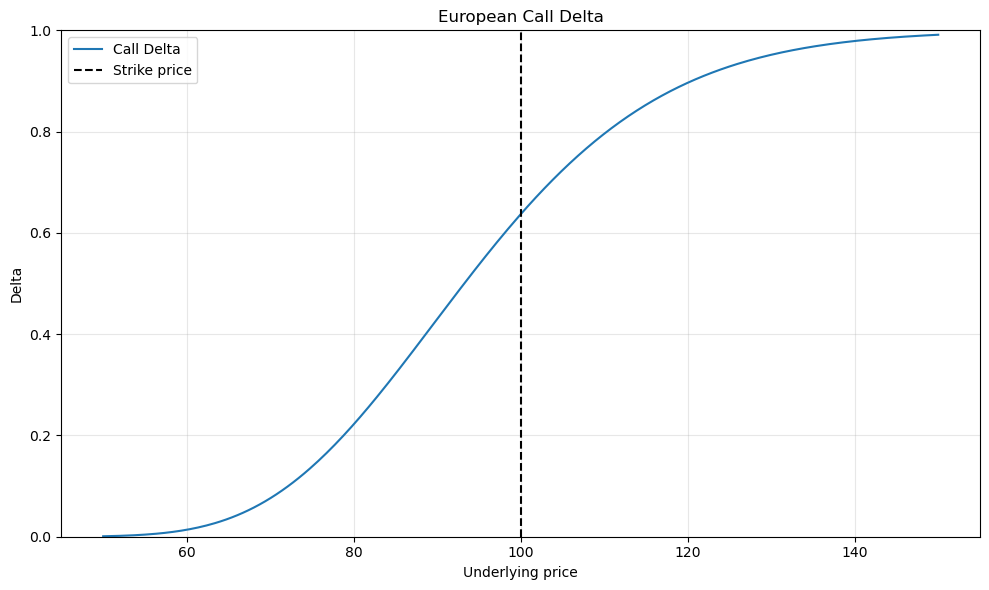

In [4]:
stock_prices = np.linspace(50, 150, 300)

delta_values = call_delta(
    S=stock_prices,
    K=K,
    r=r,
    sigma=sigma,
    tau=tau
)

plt.figure(figsize=(10, 6))

plt.plot(
    stock_prices,
    delta_values,
    label="Call Delta"
)

plt.axvline(
    K,
    color="black",
    linestyle="--",
    label="Strike price"
)

plt.xlabel("Underlying price")
plt.ylabel("Delta")
plt.title("European Call Delta")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Gamma

Gamma measures how quickly Delta changes as the underlying price changes:

$$
\Gamma
=
\frac{\partial \Delta}{\partial S}
=
\frac{\partial^2 C}{\partial S^2}.
$$

For both European calls and puts under the Black–Scholes model,

$$
\Gamma=\frac{\phi(d_1)}{S\sigma\sqrt{\tau}}.
$$

Gamma captures the curvature of the option-price function and is
typically concentrated near the strike price.

In [5]:
def option_gamma(S, K, r, sigma, tau):
    """Calculate the Gamma of a European call or put."""

    d1 = calculate_d1(S, K, r, sigma, tau)

    return norm.pdf(d1) / (
        S * sigma * np.sqrt(tau)
    )

In [6]:
gamma = option_gamma(
    S=100,
    K=100,
    r=0.05,
    sigma=0.20,
    tau=1
)

print(f"Gamma: {gamma:.4f}")

Gamma: 0.0188


### Gamma Across Underlying Prices

Gamma is generally concentrated near the strike price, but its exact
maximum as a function of the spot price need not occur at $S=K$.

Under the assumptions used here, the maximum occurs at

$$
S_{\text{peak}}
=
K\exp\left[-\left(r+\frac{3}{2}\sigma^2\right)\tau\right].
$$

Far in-the-money and far out-of-the-money options have lower Gamma
because their Delta values are already close to one or zero.

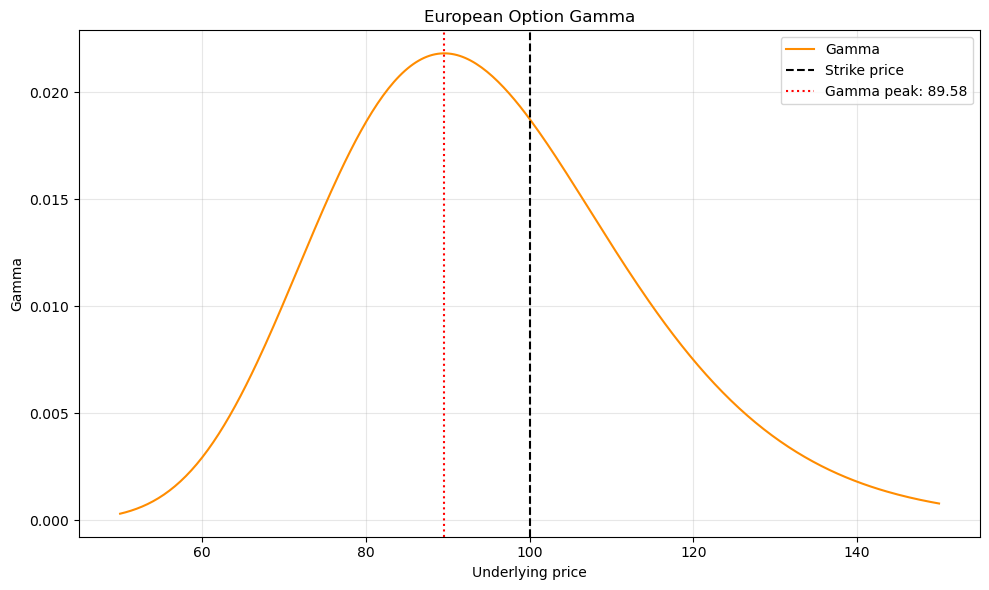

In [7]:
gamma_values = option_gamma(
    S=stock_prices,
    K=K,
    r=r,
    sigma=sigma,
    tau=tau
)

plt.figure(figsize=(10, 6))

plt.plot(
    stock_prices,
    gamma_values,
    label="Gamma",
    color="darkorange"
)

plt.axvline(
    K,
    color="black",
    linestyle="--",
    label="Strike price"
)

gamma_peak_price = K * np.exp(
    -(r + 1.5 * sigma**2) * tau
)

plt.axvline(
    gamma_peak_price,
    color="red",
    linestyle=":",
    label=f"Gamma peak: {gamma_peak_price:.2f}"
)

plt.xlabel("Underlying price")
plt.ylabel("Gamma")
plt.title("European Option Gamma")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Vega

Vega measures the sensitivity of the option price to volatility:

$$
\text{Vega}=\frac{\partial C}{\partial \sigma}.
$$

For both European calls and puts under the Black–Scholes model,

$$
\text{Vega}=S\phi(d_1)\sqrt{\tau}.
$$

The formula measures the price change for a change of $1.00$ in
volatility. Market convention often reports Vega for a one-percentage-
point change in volatility, so the raw result is divided by 100.

In [8]:
def option_vega(S, K, r, sigma, tau):
    """
    Calculate Vega for a 1.00 change in volatility.
    Divide by 100 for a one-percentage-point change.
    """

    d1 = calculate_d1(S, K, r, sigma, tau)

    return S * norm.pdf(d1) * np.sqrt(tau)

In [9]:
vega_raw = option_vega(
    S=100,
    K=100,
    r=0.05,
    sigma=0.20,
    tau=1
)

vega_one_percent = vega_raw / 100

print(f"Raw Vega:              {vega_raw:.4f}")
print(f"Vega per 1 percentage point: {vega_one_percent:.4f}")

Raw Vega:              37.5240
Vega per 1 percentage point: 0.3752


### Vega Across Underlying Prices

Vega is concentrated near the strike price because uncertainty about
whether the option will finish in or out of the money matters most in
that region.

As a function of the spot price, its maximum occurs at

$$
S_{\text{peak}}
=
K\exp\left[\left(\frac{1}{2}\sigma^2-r\right)\tau\right].
$$

The graph reports Vega for a one-percentage-point change in volatility.

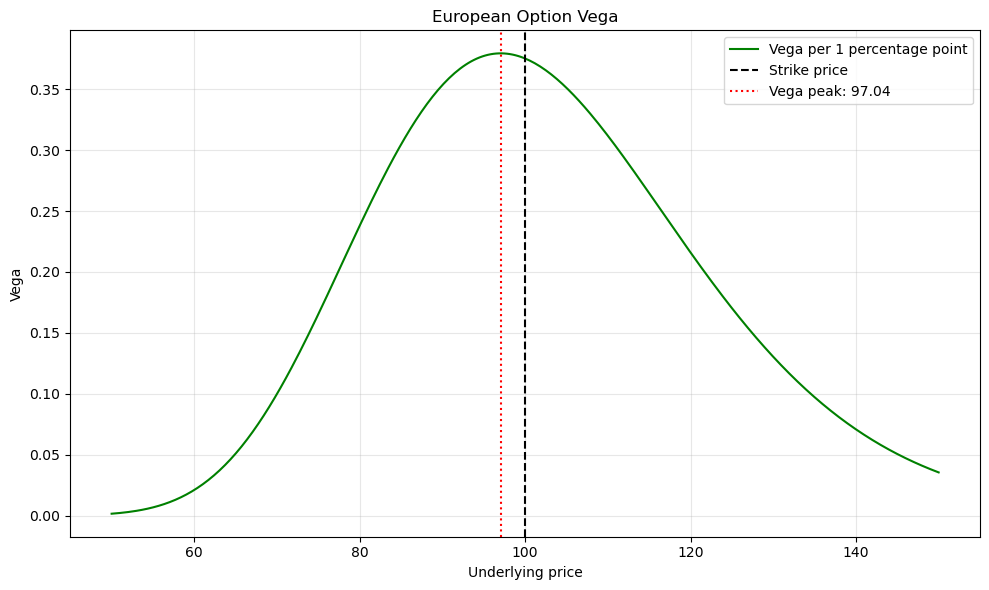

In [10]:
vega_values = option_vega(
    S=stock_prices,
    K=K,
    r=r,
    sigma=sigma,
    tau=tau
) / 100

vega_peak_price = K * np.exp(
    (0.5 * sigma**2 - r) * tau
)

plt.figure(figsize=(10, 6))

plt.plot(
    stock_prices,
    vega_values,
    label="Vega per 1 percentage point",
    color="green"
)

plt.axvline(
    K,
    color="black",
    linestyle="--",
    label="Strike price"
)

plt.axvline(
    vega_peak_price,
    color="red",
    linestyle=":",
    label=f"Vega peak: {vega_peak_price:.2f}"
)

plt.xlabel("Underlying price")
plt.ylabel("Vega")
plt.title("European Option Vega")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Theta

Theta measures the change in the option price as calendar time passes:

$$
\Theta
=
\frac{\partial C}{\partial t}
=
-\frac{\partial C}{\partial \tau},
$$

where $\tau=T-t$ is the remaining time to maturity.

For a non-dividend-paying European call,

$$
\Theta_{\text{call}}
=
-\frac{S\phi(d_1)\sigma}{2\sqrt{\tau}}
-rKe^{-r\tau}N(d_2).
$$

This formula reports annualised Theta. Dividing by 365 gives an
approximate calendar-day Theta.

In [11]:
def calculate_d2(S, K, r, sigma, tau):
    """Calculate d2 in the Black-Scholes model."""

    d1 = calculate_d1(S, K, r, sigma, tau)
    return d1 - sigma * np.sqrt(tau)


def call_theta(S, K, r, sigma, tau):
    """Calculate annualised Theta for a European call."""

    d1 = calculate_d1(S, K, r, sigma, tau)
    d2 = calculate_d2(S, K, r, sigma, tau)

    time_value_term = (
        -S * norm.pdf(d1) * sigma
        / (2 * np.sqrt(tau))
    )

    discounting_term = (
        -r * K * np.exp(-r * tau)
        * norm.cdf(d2)
    )

    return time_value_term + discounting_term

In [12]:
theta_annual = call_theta(
    S=100,
    K=100,
    r=0.05,
    sigma=0.20,
    tau=1
)

theta_daily = theta_annual / 365

print(f"Annualised Theta: {theta_annual:.4f}")
print(f"Calendar-day Theta: {theta_daily:.4f}")

Annualised Theta: -6.4140
Calendar-day Theta: -0.0176


### Theta Across Underlying Prices

Theta reflects both the loss of time value and the effect of discounting
the strike price.

Its shape depends on the underlying price, volatility, interest rate and
remaining maturity. The graph below reports approximate calendar-day
Theta.

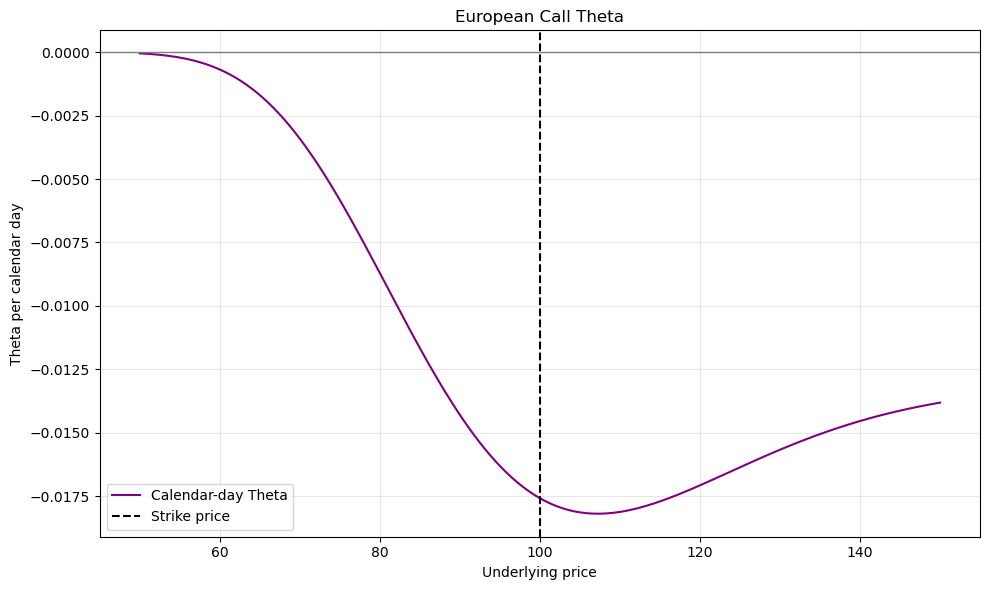

In [13]:
theta_values = call_theta(
    S=stock_prices,
    K=K,
    r=r,
    sigma=sigma,
    tau=tau
) / 365

plt.figure(figsize=(10, 6))

plt.plot(
    stock_prices,
    theta_values,
    label="Calendar-day Theta",
    color="purple"
)

plt.axvline(
    K,
    color="black",
    linestyle="--",
    label="Strike price"
)

plt.axhline(
    0,
    color="grey",
    linewidth=1
)

plt.xlabel("Underlying price")
plt.ylabel("Theta per calendar day")
plt.title("European Call Theta")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Finite-Difference Validation

The analytical Greeks can be validated by numerically differentiating
the Black–Scholes option price.

The central-difference approximations for Delta and Gamma are

$$
\Delta
\approx
\frac{C(S+h)-C(S-h)}{2h},
$$

and

$$
\Gamma
\approx
\frac{C(S+h)-2C(S)+C(S-h)}{h^2}.
$$

For sufficiently small $h$, these numerical estimates should be close
to the analytical formulas.

In [14]:
def black_scholes_call_price(S, K, r, sigma, tau):
    """Calculate the Black-Scholes price of a European call."""

    d1 = calculate_d1(S, K, r, sigma, tau)
    d2 = calculate_d2(S, K, r, sigma, tau)

    return (
        S * norm.cdf(d1)
        - K * np.exp(-r * tau) * norm.cdf(d2)
    )

In [15]:
call_price = black_scholes_call_price(
    S=100,
    K=100,
    r=0.05,
    sigma=0.20,
    tau=1
)

print(f"Black-Scholes call price: {call_price:.4f}")

Black-Scholes call price: 10.4506


In [16]:
def finite_difference_greeks(
    S,
    K,
    r,
    sigma,
    tau,
    h_S=0.01,
    h_sigma=0.0001,
    h_tau=0.0001
):
    """Estimate Greeks using central finite differences."""

    if h_tau >= tau:
        raise ValueError("h_tau must be smaller than tau.")

    price = black_scholes_call_price(
        S, K, r, sigma, tau
    )

    price_S_up = black_scholes_call_price(
        S + h_S, K, r, sigma, tau
    )

    price_S_down = black_scholes_call_price(
        S - h_S, K, r, sigma, tau
    )

    delta_fd = (
        price_S_up - price_S_down
    ) / (2 * h_S)

    gamma_fd = (
        price_S_up
        - 2 * price
        + price_S_down
    ) / (h_S**2)

    price_sigma_up = black_scholes_call_price(
        S, K, r, sigma + h_sigma, tau
    )

    price_sigma_down = black_scholes_call_price(
        S, K, r, sigma - h_sigma, tau
    )

    vega_fd = (
        price_sigma_up - price_sigma_down
    ) / (2 * h_sigma)

    price_tau_up = black_scholes_call_price(
        S, K, r, sigma, tau + h_tau
    )

    price_tau_down = black_scholes_call_price(
        S, K, r, sigma, tau - h_tau
    )

    theta_fd = (
        price_tau_down - price_tau_up
    ) / (2 * h_tau)

    return {
        "Delta": delta_fd,
        "Gamma": gamma_fd,
        "Vega": vega_fd,
        "Theta": theta_fd
    }

In [17]:
analytical_greeks = {
    "Delta": call_delta(S, K, r, sigma, tau),
    "Gamma": option_gamma(S, K, r, sigma, tau),
    "Vega": option_vega(S, K, r, sigma, tau),
    "Theta": call_theta(S, K, r, sigma, tau)
}

numerical_greeks = finite_difference_greeks(
    S, K, r, sigma, tau
)

print(
    f"{'Greek':<10}"
    f"{'Analytical':>15}"
    f"{'Finite Difference':>20}"
    f"{'Absolute Error':>18}"
)

for greek in analytical_greeks:
    analytical = analytical_greeks[greek]
    numerical = numerical_greeks[greek]
    error = abs(analytical - numerical)

    print(
        f"{greek:<10}"
        f"{analytical:>15.6f}"
        f"{numerical:>20.6f}"
        f"{error:>18.2e}"
    )

Greek          Analytical   Finite Difference    Absolute Error
Delta            0.636831            0.636831          8.60e-09
Gamma            0.018762            0.018762          2.68e-10
Vega            37.524035           37.524034          3.04e-07
Theta           -6.414028           -6.414028          4.92e-09


### Finite-Difference Step Size

A smaller finite-difference step does not always produce a more accurate
result.

For large $h$, the approximation has truncation error. For extremely
small $h$, subtracting nearly equal floating-point numbers introduces
round-off error.

The following graph examines this trade-off for Delta and Gamma.

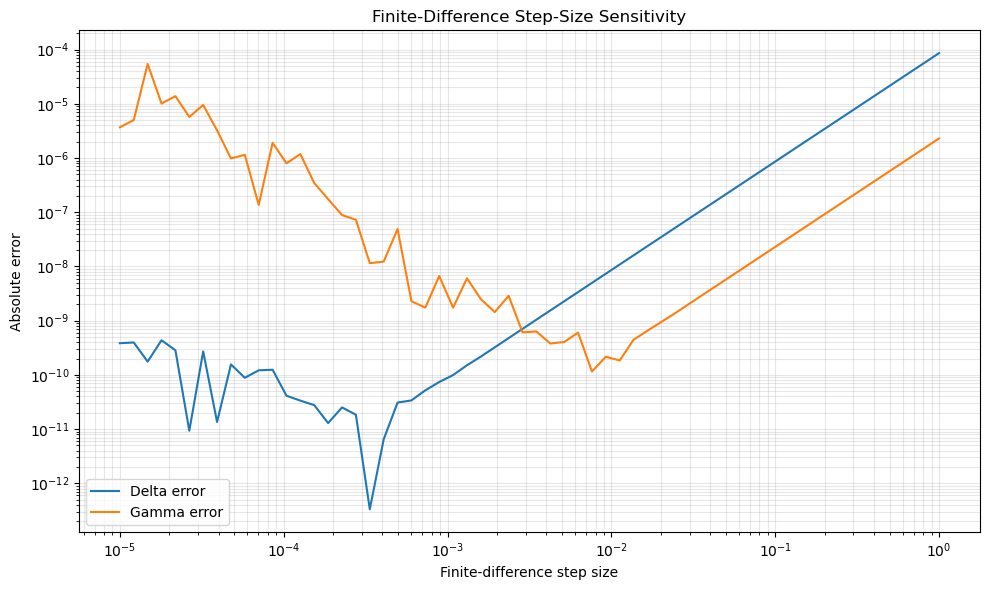

In [18]:
step_sizes = np.logspace(-5, 0, 60)

exact_delta = call_delta(S, K, r, sigma, tau)
exact_gamma = option_gamma(S, K, r, sigma, tau)

delta_errors = []
gamma_errors = []

base_price = black_scholes_call_price(
    S, K, r, sigma, tau
)

for h in step_sizes:
    price_up = black_scholes_call_price(
        S + h, K, r, sigma, tau
    )

    price_down = black_scholes_call_price(
        S - h, K, r, sigma, tau
    )

    delta_estimate = (
        price_up - price_down
    ) / (2 * h)

    gamma_estimate = (
        price_up
        - 2 * base_price
        + price_down
    ) / (h**2)

    delta_errors.append(
        abs(delta_estimate - exact_delta)
    )

    gamma_errors.append(
        abs(gamma_estimate - exact_gamma)
    )

delta_errors = np.maximum(
    delta_errors,
    np.finfo(float).eps
)

gamma_errors = np.maximum(
    gamma_errors,
    np.finfo(float).eps
)

plt.figure(figsize=(10, 6))

plt.loglog(
    step_sizes,
    delta_errors,
    label="Delta error"
)

plt.loglog(
    step_sizes,
    gamma_errors,
    label="Gamma error"
)

plt.xlabel("Finite-difference step size")
plt.ylabel("Absolute error")
plt.title("Finite-Difference Step-Size Sensitivity")
plt.legend()
plt.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

## Conclusion

This notebook implemented analytical Black–Scholes formulas for Delta,
Gamma, Vega and Theta and visualised their dependence on the underlying
asset price.

The analytical results were validated using central finite differences.
At the benchmark parameters, all four numerical estimates closely
matched their analytical counterparts.

The step-size experiment demonstrated the trade-off between truncation
error and floating-point round-off error. Both Delta and Gamma errors
initially decreased as the step size became smaller, before increasing
again for extremely small steps.